In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
from datetime import datetime
pd.set_option('display.max_rows', None)

In [2]:
#print(tf.config.list_physical_devices('GPU'))

In [3]:
componentsA = pd.read_csv('data/SCLDDoS2024_SetA_components.csv')
eventsA = pd.read_csv('data/SCLDDoS2024_SetA_events.csv')
componentsB = pd.read_csv('data/SCLDDoS2024_SetB_components.csv')
eventsB = pd.read_csv('data/SCLDDoS2024_SetB_events.csv')
componentsC = pd.read_csv('data/SCLDDoS2024_SetC_components.csv')
eventsC = pd.read_csv('data/SCLDDoS2024_SetC_events.csv')
componentsD = pd.read_csv('data/SCLDDoS2024_SetD_components.csv')
eventsD = pd.read_csv('data/SCLDDoS2024_SetD_events.csv')

In [4]:
eventsA.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsB.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsC.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsD.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)

In [5]:
A = pd.merge(eventsA, componentsA, on='Attack ID')
B = pd.merge(eventsB, componentsB, on='Attack ID')
C = pd.merge(eventsC, componentsC, on='Attack ID')
D = pd.merge(eventsD, componentsD, on='Attack ID')

In [6]:
train = pd.concat([A, B])
test = C
val = D

In [7]:
train[train['Attack ID']==93].head(5)

,Attack ID,Avg source IP count,Start time,End time,Type,Detect count,Card,Victim IP,Port number,Attack code,Significant flag,Packet speed,Data speed,Avg packet len,Source IP count,Time
196,93,1,2022-08-09T00:23:48,2022-08-09T00:23:49,DDoS attack,1,sga10gq0,IP_0021,0,DNS,0,36200,48,1367,1,2022-08-09T00:23:48


In [8]:
from sklearn.preprocessing import LabelEncoder
#0-DDoS, 1-Normal, 2-Suspicious
# Initialize LabelEncoder
le = LabelEncoder()

# Transform 'Type' column
train['Type'] = le.fit_transform(train['Type'])
test['Type'] = le.fit_transform(test['Type'])
val['Type'] = le.fit_transform(val['Type'])

In [9]:
train[train['Attack ID']==93].head(5)

,Attack ID,Avg source IP count,Start time,End time,Type,Detect count,Card,Victim IP,Port number,Attack code,Significant flag,Packet speed,Data speed,Avg packet len,Source IP count,Time
196,93,1,2022-08-09T00:23:48,2022-08-09T00:23:49,0,1,sga10gq0,IP_0021,0,DNS,0,36200,48,1367,1,2022-08-09T00:23:48


In [10]:
"""def count_differences(df, col_x, col_y):
    return (df[col_x] != df[col_y]).sum() / len(df) * 100

columns_to_compare = [
    ('Significant flag_x', 'Significant flag_y'),
    ('Card_x', 'Card_y'),
    ('Victim IP_x', 'Victim IP_y'),
    ('Port number_x', 'Port number_y'),
    ('Attack code_x', 'Attack code_y'),
    ('Detect count_x', 'Detect count_y'),
    ('Packet speed_x', 'Packet speed_y'),
    ('Data speed_x', 'Data speed_y'),
    ('Avg packet len_x', 'Avg packet len_y')
]

for col_x, col_y in columns_to_compare:
    train[f'diff_{col_x}_{col_y}'] = count_differences(train, col_x, col_y)
    test[f'diff_{col_x}_{col_y}'] = count_differences(test, col_x, col_y)
    val[f'diff_{col_x}_{col_y}'] = count_differences(val, col_x, col_y)

train.head()"""

"def count_differences(df, col_x, col_y):\n    return (df[col_x] != df[col_y]).sum() / len(df) * 100\n\ncolumns_to_compare = [\n    ('Significant flag_x', 'Significant flag_y'),\n    ('Card_x', 'Card_y'),\n    ('Victim IP_x', 'Victim IP_y'),\n    ('Port number_x', 'Port number_y'),\n    ('Attack code_x', 'Attack code_y'),\n    ('Detect count_x', 'Detect count_y'),\n    ('Packet speed_x', 'Packet speed_y'),\n    ('Data speed_x', 'Data speed_y'),\n    ('Avg packet len_x', 'Avg packet len_y')\n]\n\nfor col_x, col_y in columns_to_compare:\n    train[f'diff_{col_x}_{col_y}'] = count_differences(train, col_x, col_y)\n    test[f'diff_{col_x}_{col_y}'] = count_differences(test, col_x, col_y)\n    val[f'diff_{col_x}_{col_y}'] = count_differences(val, col_x, col_y)\n\ntrain.head()"

In [11]:
train.drop(columns=['Card', 'Significant flag'], inplace=True)
test.drop(columns=['Card', 'Significant flag'], inplace=True)
val.drop(columns=['Card', 'Significant flag'], inplace=True)

In [12]:
num_cols = train.select_dtypes(include=[np.number]).columns
num_cols

Index(['Attack ID', 'Avg source IP count', 'Type', 'Detect count',
       'Port number', 'Packet speed', 'Data speed', 'Avg packet len',
       'Source IP count'],
      dtype='object')

for column in num_cols:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train[column])
plt.title(f'Boxplot for {column}')
plt.show()


In [13]:
train = train[train['End time'] != '0']
test = test[test['End time'] != '0']
val = val[val['End time'] != '0']

In [14]:
dataframes = {'train': train, 'test': test, 'val': val}

In [15]:
""" Attack code removed"""
"""cat_cols = ['Attack code']

from sklearn.preprocessing import MultiLabelBinarizer

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    train[cat] = train[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(train[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    train = train.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    test[cat] = test[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(test[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    test = test.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    val[cat] = val[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(val[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    val = val.join(encoded_categories)
train.head()"""

"cat_cols = ['Attack code']\n\nfrom sklearn.preprocessing import MultiLabelBinarizer\n\nfor cat in cat_cols:\n    # 🔹 Step 1: Convert comma-separated strings into lists\n    train[cat] = train[cat].apply(lambda x: x.split(','))\n\n    # 🔹 Step 2: Use MultiLabelBinarizer to encode\n    mlb = MultiLabelBinarizer()\n    encoded_categories = pd.DataFrame(mlb.fit_transform(train[cat]), columns=mlb.classes_)\n    encoded_categories = encoded_categories.add_prefix(f'{cat}_')\n\n    # 🔹 Step 3: Merge back with original DataFrame\n    train = train.join(encoded_categories)\n\nfor cat in cat_cols:\n    # 🔹 Step 1: Convert comma-separated strings into lists\n    test[cat] = test[cat].apply(lambda x: x.split(','))\n\n    # 🔹 Step 2: Use MultiLabelBinarizer to encode\n    mlb = MultiLabelBinarizer()\n    encoded_categories = pd.DataFrame(mlb.fit_transform(test[cat]), columns=mlb.classes_)\n    encoded_categories = encoded_categories.add_prefix(f'{cat}_')\n\n    # 🔹 Step 3: Merge back with original 

In [16]:
import re
train['Victim IP'] = train['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))
test['Victim IP'] = test['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))
val['Victim IP'] = val['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))

C:\Users\Admin\AppData\Local\Temp\ipykernel_1232\3418480291.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['Victim IP'] = val['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))


In [17]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Packet speed', 'Data speed', 'Avg packet len']

scaler = MinMaxScaler()

train[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(train[columns_to_scale])
test[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(test[columns_to_scale])
val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])

C:\Users\Admin\AppData\Local\Temp\ipykernel_1232\3689095016.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])
C:\Users\Admin\AppData\Local\Temp\ipykernel_1232\3689095016.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])
C:\Users\Admin\AppData\Local\Temp\ipykernel_1232\3689095016.py:9: SettingWithCopyWarni

In [18]:
train.columns

Index(['Attack ID', 'Avg source IP count', 'Start time', 'End time', 'Type',
       'Detect count', 'Victim IP', 'Port number', 'Attack code',
       'Packet speed', 'Data speed', 'Avg packet len', 'Source IP count',
       'Time', 'Packet speed_normalized', 'Data speed_normalized',
       'Avg packet len_normalized'],
      dtype='object')

In [19]:
# Drop columns starting with 'diff_'
train = train[[col for col in train.columns if not col.startswith('diff_')]]
test = test[[col for col in test.columns if not col.startswith('diff_')]]
val = val[[col for col in val.columns if not col.startswith('diff_')]]

In [20]:
train.to_parquet('data/train.parquet', index=False)
test.to_parquet('data/test.parquet', index=False)
val.to_parquet('data/val.parquet', index=False)

In [21]:
x_cols = ['Attack ID', 'Avg source IP count',
       'Detect count', 'Victim IP', 'Port number', 'Packet speed',
       'Data speed', 'Avg packet len', 'Source IP count',
       'Packet speed_normalized', 'Data speed_normalized',
       'Avg packet len_normalized']

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rfc = RandomForestClassifier(random_state=42, verbose=1)

rfc.fit(train[x_cols], train['Type'])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.3min


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
# Predict the labels for the test data
val['pred'] = rfc.predict(val[x_cols])

# Evaluate the model
accuracy = accuracy_score(val['Type'], val['pred'])
print("Accuracy:", accuracy)
precision = precision_score(val['Type'], val['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(val['Type'], val['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(val['Type'], val['pred'], average='macro')
print("F1-Score:", f1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.7s


Accuracy: 0.4724993429891114
Precision: 0.6515956885178632
Recall: 0.48586386788520947
F1-Score: 0.4329523690377064


In [24]:
feature_importances = pd.Series(rfc.feature_importances_, index=x_cols)
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
Attack ID                    0.335192
Detect count                 0.143287
Avg source IP count          0.114237
Source IP count              0.058091
Victim IP                    0.055070
Port number                  0.052177
Packet speed                 0.047374
Packet speed_normalized      0.042173
Data speed_normalized        0.040139
Data speed                   0.038833
Avg packet len               0.037163
Avg packet len_normalized    0.036264
dtype: float64


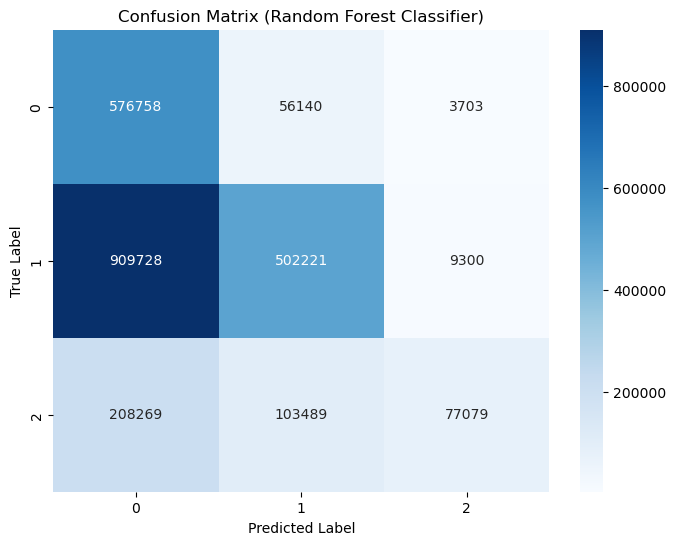

Confusion Matrix (Random Forest Classifier):
 [[576758  56140   3703]
 [909728 502221   9300]
 [208269 103489  77079]]


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(val['Type'], val['pred'])

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(val['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [26]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(val['pred'], val['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.91      0.34      0.49   1694755
           1       0.35      0.76      0.48    661850
           2       0.20      0.86      0.32     90082

    accuracy                           0.47   2446687
   macro avg       0.49      0.65      0.43   2446687
weighted avg       0.73      0.47      0.49   2446687



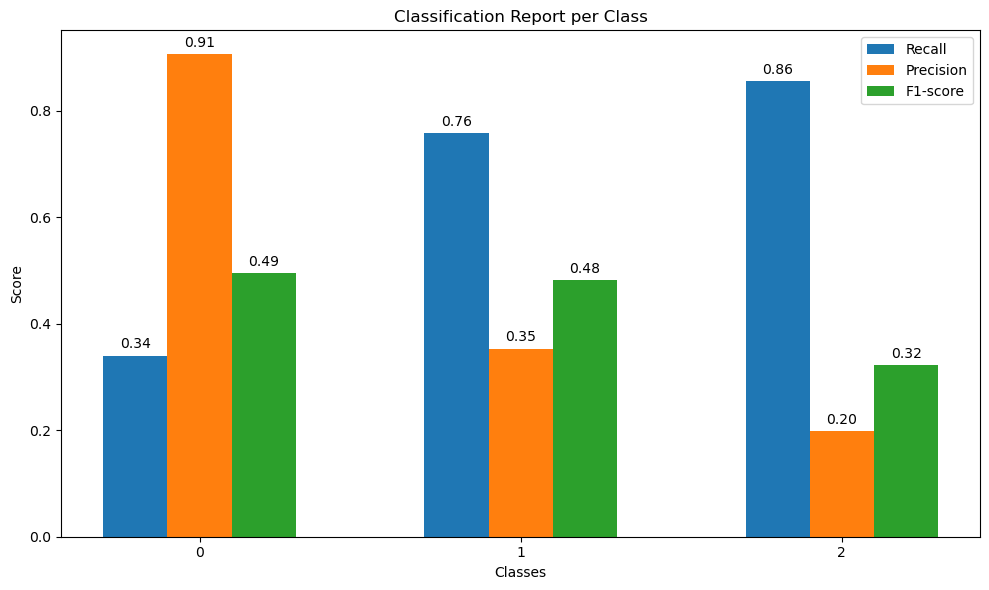

In [27]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the classification report as a dictionary
report = classification_report(val['Type'], val['pred'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()